In [13]:
from pathlib import Path
import sys
import importlib

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import ipywidgets as widgets
from IPython.display import display

# Notebook location expected:
NB_DIR = Path.cwd()
OCGM_DIR = NB_DIR.parent
PROJECT_DIR = OCGM_DIR.parent

for path in [PROJECT_DIR, OCGM_DIR / "scripts"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import theme.plot_theme as ptheme
import ocean_analysis_adjusted as oa

# Reload during notebook development
importlib.reload(ptheme)
ptheme.apply_theme()
importlib.reload(oa)


c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


<module 'ocean_analysis_adjusted' from 'c:\\Users\\Jelle Gortemaker\\Documents\\Thesis\\OGCM\\scripts\\ocean_analysis_adjusted.py'>

Red box lat range: 22.14 to 23.86
Red box lon range: -140.94 to -139.06
Vortex box saving is DEACTIVATED.


c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\

(<Figure size 1200x600 with 2 Axes>,
 <GeoAxes: title={'center': 'GPGP Vortex Detection January 2020'}>)

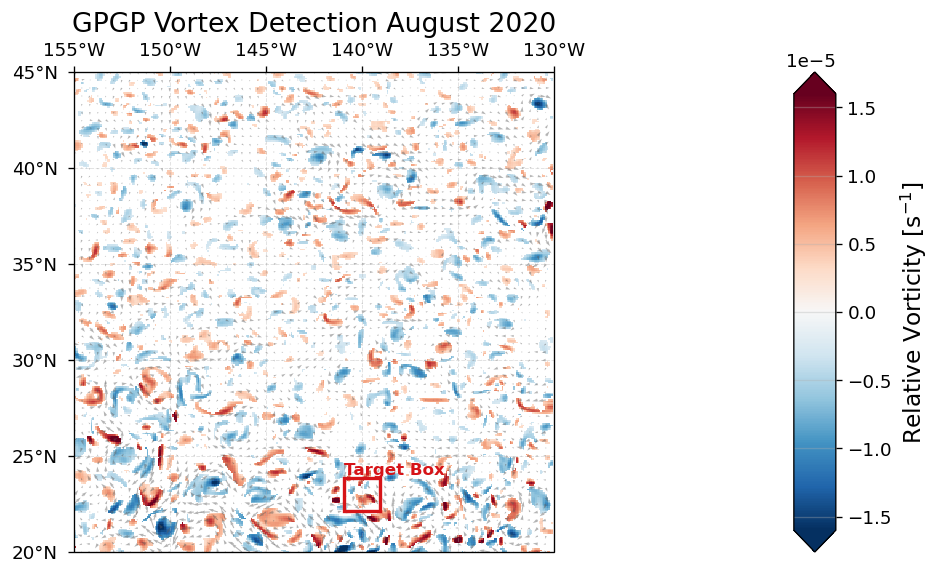

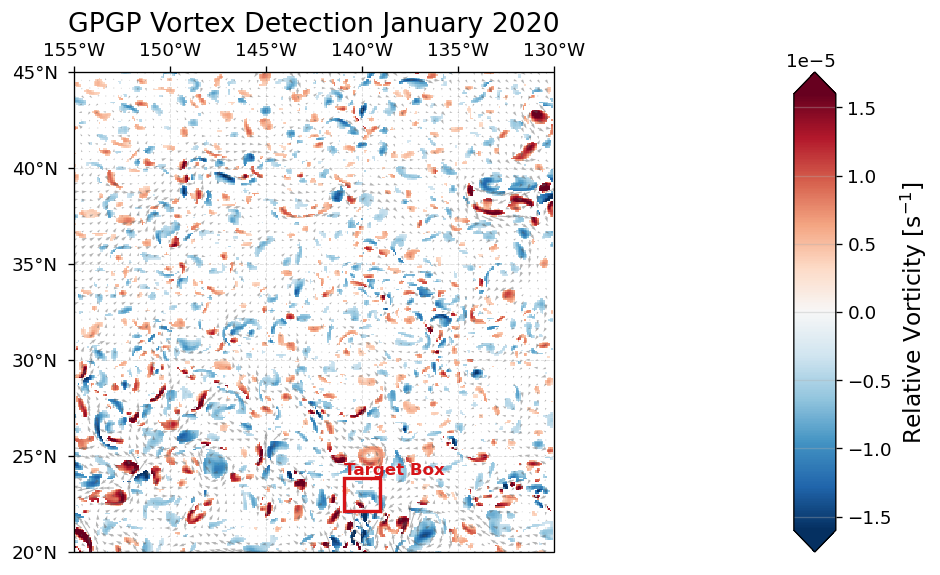

In [14]:
# 1. Load Data

surface_ds_2020 = oa.process_glorys_data('../data/input/GPGP_aug2020.nc', averaging_period='1D')
surface_ds_2021 = oa.process_glorys_data('../data/input/GPGP_aug2021.nc', averaging_period='1D')
surface_ds_2022 = oa.process_glorys_data('../data/input/GPGP_aug2022.nc', averaging_period='1D')
surface_ds_2023 = oa.process_glorys_data('../data/input/GPGP_aug2023.nc', averaging_period='1D')
surface_ds_2020_winter = oa.process_glorys_data('../data/input/GPGP_jan2020.nc', averaging_period='1D')
surface_ds_2021_winter = oa.process_glorys_data('../data/input/GPGP_jan2021.nc', averaging_period='1D')
surface_ds_2022_winter = oa.process_glorys_data('../data/input/GPGP_jan2022.nc', averaging_period='1D')
surface_ds_2023_winter = oa.process_glorys_data('../data/input/GPGP_jan2023.nc', averaging_period='1D')


# 2. Compute Metrics

results_2020 = oa.calculate_okubo_weiss(surface_ds_2020)
signed_vort_2020, mask_2020 = oa.get_eddy_intensity(results_2020, alpha=0.2)
results_2020_winter = oa.calculate_okubo_weiss(surface_ds_2020_winter)
signed_vort_2020_winter, mask_2020_winter = oa.get_eddy_intensity(results_2020_winter, alpha=0.2)

    
# 3. SELECT TARGET DOMAIN
# lat_s, lat_n = 25.0, 27.0
# lon_w, lon_e = -145.0, -143.0
# lat_s, lat_n = 22.5, 27.5
# lon_w, lon_e = -145.0, -140.0
# lat_s, lat_n = 20.0, 45.0 # whole GPGP
# lon_w, lon_e = -155.0, -130.0 # whole GPGP
# lat_s, lat_n = 22.5, 27.5
# lon_w, lon_e = -145.0, -140.0
center_lat = 23.0
center_lon = -140.0

dlat = 192 / 111.32          # ≈ 1.725 deg
dlon = 192 / (111.32 * np.cos(np.deg2rad(center_lat)))   # ≈ 1.903 deg

lat_s = center_lat - dlat/2
lat_n = center_lat + dlat/2
lon_w = center_lon - dlon/2
lon_e = center_lon + dlon/2

print(f"Red box lat range: {lat_s:.2f} to {lat_n:.2f}")
print(f"Red box lon range: {lon_w:.2f} to {lon_e:.2f}")


les_box = oa.get_subdomain(lat_min=lat_s, lon_min=lon_w, lat_max=lat_n, lon_max=lon_e)

# Preprocess for Vortex Fitting

oa.preprocess_netcdf(surface_ds_2020, les_box, base_name='GPGP_aug2020', active=False, subtract_mean=True) 

# 4. Visualize with the Red Rectangle
oa.plot_eddy_intensity(signed_vort_2020, u=surface_ds_2020.uo, v=surface_ds_2020.vo, 
                       title="GPGP Vortex Detection August 2020",
                       target_box=les_box)

oa.plot_eddy_intensity(signed_vort_2020_winter, u=surface_ds_2020_winter.uo, v=surface_ds_2020_winter.vo, 
                       title="GPGP Vortex Detection January 2020",
                       target_box=les_box)


# # 5. Extract statistics strictly inside that box
# box_data = signed_vort.sel(longitude=slice(les_box[0], les_box[1]), 
#                            latitude=slice(les_box[2], les_box[3]))

# print(f"Stats for red box:")
# print(f"Number of eddy core pixels: {int(box_data.notnull().sum())}")

Vortex box saving is DEACTIVATED.


c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
c:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)


(<Figure size 1200x600 with 2 Axes>,
 <GeoAxes: title={'center': 'GPGP Vortex Detection August 2020'}>)

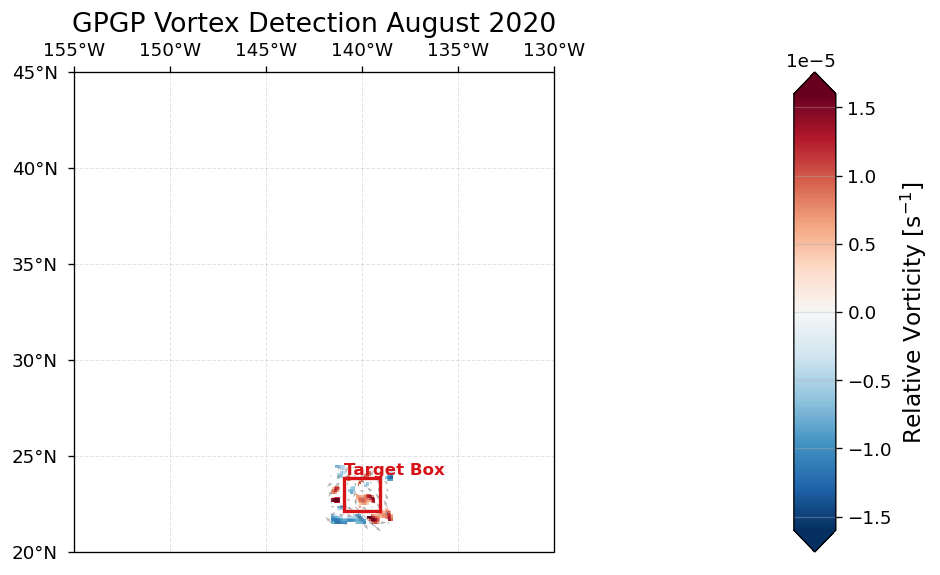

In [15]:
# 1. Load Data

surface_ds_2020_ROI = oa.process_glorys_data('../data/input/GPGP_aug2020_3D_21.5_24.5_141.6_138.4.nc', averaging_period='1D')


# 2. Compute Metrics

results_2020_ROI = oa.calculate_okubo_weiss(surface_ds_2020_ROI)
signed_vort_2020_ROI, mask_2020_ROI = oa.get_eddy_intensity(results_2020_ROI, alpha=0.2)


 


# Preprocess for Vortex Fitting

oa.preprocess_netcdf(surface_ds_2020_ROI, les_box=None, base_name='ROI_aug2020', active=False, subtract_mean=True) 

# 4. Visualize with the Red Rectangle
oa.plot_eddy_intensity(signed_vort_2020_ROI, u=surface_ds_2020_ROI.uo, v=surface_ds_2020_ROI.vo, 
                       title="GPGP Vortex Detection August 2020",
                       target_box=les_box)


In [16]:
# time_ranges_2021 = [
#     ('2021-08-01', '2021-08-01'),
#     ('2021-08-02', '2021-08-02'),
#     ('2021-08-03', '2021-08-03'),
#     ('2021-08-04', '2021-08-04'),
#     ('2021-08-05', '2021-08-05'),
#     ('2021-08-06', '2021-08-06'),
#     ('2021-08-07', '2021-08-07'),
#     ('2021-08-08', '2021-08-08'),
#     ('2021-08-09', '2021-08-09'),
#     ('2021-08-10', '2021-08-10'),
#     ('2021-08-11', '2021-08-11'),
#     ('2021-08-12', '2021-08-12'),
#     ('2021-08-13', '2021-08-13'),
#     ('2021-08-14', '2021-08-14'),
#     ('2021-08-15', '2021-08-15'),
#     ('2021-08-16', '2021-08-16'),
#     ('2021-08-17', '2021-08-17'),
#     ('2021-08-18', '2021-08-18'),
#     ('2021-08-19', '2021-08-19'),
#     ('2021-08-20', '2021-08-20'),
#     ('2021-08-21', '2021-08-21'),
#     ('2021-08-22', '2021-08-22'),
#     ('2021-08-23', '2021-08-23'),
#     ('2021-08-24', '2021-08-24'),
#     ('2021-08-25', '2021-08-25'),
#     ('2021-08-26', '2021-08-26'),
#     ('2021-08-27', '2021-08-27'),
#     ('2021-08-28', '2021-08-28'),
#     ('2021-08-29', '2021-08-29'),
#     ('2021-08-30', '2021-08-30'),
#     ('2021-08-31', '2021-08-31')
# ]

# surface_datasets_2021 = []
# ow_results_2021 = []
# signed_vort_2021_list = []
# mask_2021_list = []

# for tr in time_ranges_2021:
#     surface_ds = oa.process_glorys_data(
#         '../data/GPGP_aug2021.nc',
#         averaging_period='1D',
#         time_range=tr
#     )
    
#     results = oa.calculate_okubo_weiss(surface_ds)
#     signed_vort, mask = oa.get_eddy_intensity(results, alpha=0.2)
    
#     surface_datasets_2021.append(surface_ds)
#     ow_results_2021.append(results)
#     signed_vort_2021_list.append(signed_vort)
#     mask_2021_list.append(mask)

# def show_frame(i):
#     oa.plot_eddy_intensity(
#         signed_vort_2021_list[i],
#         u=surface_datasets_2021[i].uo,
#         v=surface_datasets_2021[i].vo,
#         title=f"GPGP Vortex Detection 2021 Summer: {time_ranges_2021[i][0]} to {time_ranges_2021[i][1]}"
#     )

# widgets.interact(
#     show_frame,
#     i=widgets.IntSlider(min=0, max=len(time_ranges_2021)-1, step=1, value=0)
# )

# frames_dir = r"C:\Users\Jelle Gortemaker\Downloads\gif_frames_2021"
# os.makedirs(frames_dir, exist_ok=True)

# for i in range(len(time_ranges_2021)):
#     fig = plt.figure(figsize=(10, 7))
#     ax = plt.axes(projection=ccrs.PlateCarree())

#     ax.add_feature(cfeature.COASTLINE)
#     ax.add_feature(cfeature.LAND, facecolor='lightgray')
#     ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)

#     im = signed_vort_2021_list[i].plot(
#         ax=ax,
#         transform=ccrs.PlateCarree(),
#         cmap='RdBu_r',
#         cbar_kwargs={'label': "Relative Vorticity [s^-1]"},
#         center=0,
#         robust=True
#     )

#     skip = 5
#     ax.quiver(
#         surface_datasets_2021[i].uo.longitude[::skip],
#         surface_datasets_2021[i].uo.latitude[::skip],
#         surface_datasets_2021[i].uo[::skip, ::skip],
#         surface_datasets_2021[i].vo[::skip, ::skip],
#         color='black',
#         alpha=0.4,
#         scale=15,
#         transform=ccrs.PlateCarree()
#     )

#     ax.set_title(
#         f"GPGP Vortex Detection 2021 Summer: "
#         f"{time_ranges_2021[i][0]} to {time_ranges_2021[i][1]}"
#     )

#     # Force identical layout for every frame
#     plt.tight_layout()

#     frame_path = os.path.join(frames_dir, f"frame_{i:02d}.png")
#     plt.savefig(frame_path, dpi=150)
#     plt.close(fig)

# print(f"Frames saved in: {frames_dir}")